## **TAHAP 1** *Membangun Case Base*

# Set Up dan Download Library

In [1]:
!pip install pymupdf pandas scikit-learn nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 36.9 MB/s eta 0:00:00


In [11]:
import os

os.makedirs("/content/data/pdf", exist_ok=True)
os.makedirs("/content/data/raw", exist_ok=True)
os.makedirs("/content/data/processed/clean_text", exist_ok=True)
os.makedirs("/content/data/eval", exist_ok=True)
os.makedirs("/content/data/logs", exist_ok=True)

print("SETUP DONE")

SETUP DONE


# PDF ke TXT

In [12]:
import fitz
import os

input_dir = "/content/data/pdf"
output_dir = "/content/data/raw"

count = 0
failed = []

for file in os.listdir(input_dir):

    if file.endswith(".pdf"):

        try:
            doc = fitz.open(os.path.join(input_dir, file))
            text = ""

            for page in doc:
                text += page.get_text()

            doc.close()

            out_path = os.path.join(output_dir, file.replace(".pdf", ".txt"))

            with open(out_path, "w", encoding="utf-8") as f:
                f.write(text)

            count += 1

        except:
            failed.append(file)

print("BERHASIL:", count)
print("GAGAL:", len(failed))

BERHASIL: 34
GAGAL: 0


# Cek hasil Raw

In [13]:
with open("/content/data/raw/case_001.txt", encoding="utf-8") as f:
    print(f.read()[:1000])

hkama
ahkamah Agung Repub
ahkamah Agung Republik Indonesia
mah Agung Republik Indonesia
blik Indonesi
Direktori Putusan Mahkamah Agung Republik Indonesia
putusan.mahkamahagung.go.id
P U T U S A N
Nomor 747/Pid.B/2025/PN Mtr
DEMI KEADILAN BERDASARKAN KETUHANAN YANG MAHA ESA
Pengadilan  Negeri  Mataram yang  mengadili  perkara  pidana  dengan
acara pemeriksaan biasa dalam tingkat pertama menjatuhkan putusan sebagai
berikut dalam perkara Terdakwa :
1. Nama lengkap 
: ABDULLAH
2. Tempat lahir 
: Mentigi
3. Umur/Tanggal lahir 
: 46 Tahun /31 Desember 1979
4. Jenis kelamin 
: Laki-laki
5. Kebangsaan 
: Indonesia
6. Tempat tinggal 
: Dusun Mentigi, Desa Malaka, Kecamatan 
Pemenang, Kabupaten Lombok Utara
7. Agama 
: Islam
8. Pekerjaan 
: Wiraswasta
Terdakwa Abdullah ditahan dalam rumah tahanan oleh : 
1. Penyidik, sejak tanggal 29 Juli 2025 sampai dengan tanggal 17 Agustus
2025. 
2. Penyidik, Perpanjangan Oleh Penuntut Umum sejak tanggal 18 Agustus 2025
sampai dengan tanggal 26 September 2025

# Cleaning Text

In [14]:
import re
import os

def clean_text(text):

    text = text.lower()

    # FIX PDF GARBAGE
    text = re.sub(r'\ba\s*h\s*agung\s*repub.*?indonesia\b',
                  'mahkamah agung republik indonesia', text)

    text = re.sub(r'direktori putusan.*?go\.id', ' ', text)
    text = re.sub(r'putusan\.mahkamahagung.*?go\.id', ' ', text)

    # hapus header umum
    text = re.sub(r'hkama', ' ', text)

    # hapus karakter aneh
    text = re.sub(r'[^a-z0-9\s\.\,\;\:\-\(\)]', ' ', text)

    # normalisasi spasi
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


raw_dir = "/content/data/raw"
clean_dir = "/content/data/processed/clean_text"

os.makedirs(clean_dir, exist_ok=True)

for file in os.listdir(raw_dir):
    if file.endswith(".txt"):

        with open(os.path.join(raw_dir, file), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        cleaned = clean_text(text)

        with open(os.path.join(clean_dir, file), "w", encoding="utf-8") as f:
            f.write(cleaned)

print("CLEANING FIXED DONE")

CLEANING FIXED DONE


# Hasil Cleaning

In [15]:
file_path = "/content/data/processed/clean_text/case_001.txt"

with open(file_path, encoding="utf-8") as f:
    print(f.read()[:1000])

a h agung repub a h agung republik indonesia mah agung republik indonesia blik indonesi direktori putusan ma h agung republik indonesia p u t u s a n nomor 747 pid.b 2025 pn mtr demi keadilan berdasarkan ketuhanan yang maha esa pengadilan negeri mataram yang mengadili perkara pidana dengan acara pemeriksaan biasa dalam tingkat pertama menjatuhkan putusan sebagai berikut dalam perkara terdakwa : 1. nama lengkap : abdullah 2. tempat lahir : mentigi 3. umur tanggal lahir : 46 tahun 31 desember 1979 4. jenis kelamin : laki-laki 5. kebangsaan : indonesia 6. tempat tinggal : dusun mentigi, desa malaka, kecamatan pemenang, kabupaten lombok utara 7. agama : islam 8. pekerjaan : wiraswasta terdakwa abdullah ditahan dalam rumah tahanan oleh : 1. penyidik, sejak tanggal 29 juli 2025 sampai dengan tanggal 17 agustus 2025. 2. penyidik, perpanjangan oleh penuntut umum sejak tanggal 18 agustus 2025 sampai dengan tanggal 26 september 2025. 3. penuntut umum, sejak tanggal 26 september 2025 sampai denga

In [16]:
print("RAW FILES:", len(os.listdir("/content/data/raw")))
print("CLEAN FILES:", len(os.listdir("/content/data/processed/clean_text")))

RAW FILES: 34
CLEAN FILES: 34


# VALIDASI KEUTUHAN TEKS


In [17]:
valid = []
invalid = []

for file in os.listdir(clean_dir):

    if not file.endswith(".txt"):
        continue

    path = os.path.join(clean_dir, file)

    with open(path, encoding="utf-8") as f:
        text = f.read()

    if len(text.split()) > 500:
        valid.append(file)
    else:
        invalid.append(file)

print("VALID:", len(valid))
print("INVALID:", len(invalid))

if len(valid) >= 30:
    print("MEMENUHI MINIMAL 30 DOKUMEN")
else:
    print("BELUM MEMENUHI MINIMAL 30 DOKUMEN")

VALID: 34
INVALID: 0
MEMENUHI MINIMAL 30 DOKUMEN


# **TAHAP 2** *Case Representation*

In [18]:
import os
import re
import pandas as pd

# Load Data Clean

In [19]:
clean_dir = "/content/data/processed/clean_text"

# Normalisasi

In [20]:
def normalize(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text

# Case Representation

In [21]:
rows = []

for file in valid:

    if not file.endswith(".txt"):
        continue

    with open(
        os.path.join(clean_dir, file),
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:
        text = f.read()

    text = normalize(text)

    # METADATA

    no_perkara = ""
    tanggal = ""
    terdakwa = ""

    m_no = re.search(
        r'putusan\s*nomor\s*[:\-]?\s*([0-9/\.a-z]+)',
        text
    )

    if m_no:
        no_perkara = m_no.group(1)

    m_tgl = re.search(
        r'tanggal\s*[:\-]?\s*([^,\.]+)',
        text
    )

    if m_tgl:
        tanggal = m_tgl.group(1)

    m_td = re.search(
        r'nama lengkap\s*[:\-]?\s*(.*?)(tempat lahir|umur|jenis kelamin|kebangsaan)',
        text
    )

    if m_td:
        terdakwa = m_td.group(1).strip()

    # FAKTA

    m_fakta = re.search(
        r'(menimbang.*?)(amar putusan|putusan|$)',
        text
    )

    if m_fakta:
        ringkasan_fakta = (
            m_fakta.group(1)[:1500]
        )
    else:
        ringkasan_fakta = (
            " ".join(
                text.split()[:300]
            )
        )

    # PASAL

    pasals = re.findall(
        r'pasal\s*[0-9a-z\s]+',
        text
    )

    pasal = ", ".join(
        sorted(
            set(pasals)
        )
    )

    # AMAR

    m_amar = re.search(
        r'amar\s*putusan(.*?)(menimbang|demikian|putusan|$)',
        text
    )

    if m_amar:
        amar_putusan = (
            m_amar.group(1)
            .strip()[:800]
        )
    else:
        amar_putusan = ""

    argumen_hukum = (
        pasal
        + " "
        + amar_putusan
    ).strip()

    word_count = len(
        text.split()
    )

    char_count = len(
        text
    )

    # LABEL

    jenis_perkara = "lain"

    if (
        "pemerasan" in text
        and
        "pengancaman" in text
    ):
        jenis_perkara = (
            "pemerasan_dan_pengancaman"
        )

    elif "pemerasan" in text:
        jenis_perkara = (
            "pemerasan"
        )

    elif "pengancaman" in text:
        jenis_perkara = (
            "pengancaman"
        )

    rows.append({

        "case_id":
        file.replace(
            ".txt",
            ""
        ),

        "no_perkara":
        no_perkara,

        "tanggal":
        tanggal,

        "jenis_perkara":
        jenis_perkara,

        "terdakwa":
        terdakwa,

        "pasal":
        pasal,

        "ringkasan_fakta":
        ringkasan_fakta,

        "argumen_hukum":
        argumen_hukum,

        "amar_putusan":
        amar_putusan,

        "word_count":
        word_count,

        "char_count":
        char_count,

        "text_full":
        text
    })

print(
    "TOTAL CASE:",
    len(rows)
)

TOTAL CASE: 34


In [22]:
df = pd.DataFrame(rows)

output_path = "/content/data/processed/cases.csv"

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("SAVED:", output_path)

print(
    "SHAPE:",
    df.shape
)

print(
    df[
        [
            "case_id",
            "jenis_perkara",
            "pasal"
        ]
    ].head()
)

print(
    df["jenis_perkara"]
    .value_counts()
)

SAVED: /content/data/processed/cases.csv
SHAPE: (34, 12)
    case_id jenis_perkara                                              pasal
0  case_026   pengancaman                                    pasal 335 ayat 
1  case_015   pengancaman     pasal 170 ayat , pasal 44 kuhp, pasal 55 ayat 
2  case_023   pengancaman                                    pasal 335 ayat 
3  case_009   pengancaman                                    pasal 335 ayat 
4  case_001   pengancaman  pasal 3 ayat , pasal 335 ayat , pasal 448 ayat...
jenis_perkara
pengancaman                  15
pemerasan_dan_pengancaman    10
pemerasan                     8
lain                          1
Name: count, dtype: int64


# **TAHAP 3** *Case Retrieval*

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load Case Base

In [24]:
df = pd.read_csv("/content/data/processed/cases.csv")

df.head()

,case_id,no_perkara,tanggal,jenis_perkara,terdakwa,pasal,ringkasan_fakta,argumen_hukum,amar_putusan,word_count,char_count,text_full
0,case_026,352.0,lahir : 45 tahun 8 agustus 1979; 4,pengancaman,fathurrahman; 2.,pasal 335 ayat,"menimbang, bahwa terdakwa diajukan ke persidan...",pasal 335 ayat,NaN,5457,37202,a h agung repub a h agung republik indonesia m...
1,case_015,450.0,lahir : 50 tahun 1 juli 1975 4,pengancaman,muhadi 2.,"pasal 170 ayat , pasal 44 kuhp, pasal 55 ayat","menimbang, bahwa para terdakwa diajukan ke per...","pasal 170 ayat , pasal 44 kuhp, pasal 55 ayat",NaN,23271,162746,a h agung repub a h agung republik indonesia m...
2,case_023,319.0,30 maret 2018; terdakwa ditahan di rumah tahan...,pengancaman,murnawadi,pasal 335 ayat,"menimbang, bahwa berdasarkan surat dakwaan pen...",pasal 335 ayat ini;,ini;,5543,38219,a h agung repub a h agung republik indonesia m...
3,case_009,319.0,30 maret 2018; terdakwa ditahan di rumah tahan...,pengancaman,murnawadi,pasal 335 ayat,"menimbang, bahwa berdasarkan surat dakwaan pen...",pasal 335 ayat ini;,ini;,5543,38219,a h agung repub a h agung republik indonesia m...
4,case_001,747.0,lahir : 46 tahun 31 desember 1979 4,pengancaman,abdullah 2.,"pasal 3 ayat , pasal 335 ayat , pasal 448 ayat...","menimbang, bahwa terdakwa diajukan ke persidan...","pasal 3 ayat , pasal 335 ayat , pasal 448 ayat...",ini ;,10273,71216,a h agung repub a h agung republik indonesia m...


# Siapkan Data Teks

In [25]:
df["combined_text"]=(

    df["ringkasan_fakta"]
    .fillna("")
    .astype(str)

    + " " +

    df["argumen_hukum"]
    .fillna("")
    .astype(str)

    + " " +

    df["pasal"]
    .fillna("")
    .astype(str)
)

In [31]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print(train_df.shape)
print(test_df.shape)

print("TRAIN:", len(train_df))
print("TEST :", len(test_df))
print("RATIO:", round(len(train_df)/len(df), 2))

(27, 13)
(7, 13)
TRAIN: 27
TEST : 7
RATIO: 0.79


# TF-IDF Vector

In [32]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

train_matrix = vectorizer.fit_transform(
    train_df["combined_text"]
)

print("TFIDF:", train_matrix.shape)

TFIDF: (27, 996)


# Function Retrieval

In [33]:
def retrieve_case(query, top_k=5):

    query = str(query).lower()

    query_vec = vectorizer.transform([query])

    scores = cosine_similarity(
        query_vec,
        train_matrix
    ).flatten()

    top_idx = scores.argsort()[::-1][:top_k]

    results = train_df.iloc[top_idx].copy()

    results["similarity_score"] = scores[top_idx]

    return results[
        [
            "case_id",
            "no_perkara",
            "terdakwa",
            "pasal",
            "similarity_score"
        ]
    ]

# TEST QUERY

In [34]:
query = """
pemerasan disertai pengancaman
terdakwa meminta uang dengan ancaman
"""

retrieve_case(query, top_k=5)

,case_id,no_perkara,terdakwa,pasal,similarity_score
16,case_027,395.0,raden satrianggi nurdiyono alias anggi;,"pasal 365 ayat , pasal 368 ayat , pasal 368 ku...",0.086809
28,case_017,588.0,hasanudin alias kencrung,pasal 368 ayat,0.071177
9,case_014,739.0,ahmad jalaludin alias jalal,"pasal 335 ayat , pasal 368 ayat , pasal 368kuh...",0.068909
7,case_010,631.0,NaN,pasal 222 kuhap terdakwa harus dibebani pula u...,0.056362
11,case_021,631.0,NaN,pasal 222 kuhap terdakwa harus dibebani pula u...,0.056362


In [55]:
test_queries = [

{
"id":1,
"query":"pemerasan",
"expected":"pemerasan"
},

{
"id":2,
"query":"pengancaman",
"expected":"pengancaman"
},

{
"id":3,
"query":"pemerasan dan pengancaman",
"expected":"pemerasan_dan_pengancaman"
},

{
"id":4,
"query":"meminta uang dengan ancaman",
"expected":"pemerasan_dan_pengancaman"
},

{
"id":5,
"query":"mengancam korban",
"expected":"pengancaman"
}

]

# **TAHAP 4**  Case Solution Reuse

In [36]:
import pandas as pd

# Load Data dan buat case_solution

In [56]:
df = pd.read_csv("/content/data/processed/cases.csv")

df["amar_putusan"] = df["amar_putusan"].fillna("").astype(str)

case_solutions = dict(
    zip(
        train_df["case_id"],
        train_df["amar_putusan"]
    )
)


# Fungsi Reuse

In [57]:
def predict_outcome(query, k=5):

    results = retrieve_case(query, top_k=k)

    case_ids = results["case_id"].astype(str).values
    scores = results["similarity_score"].values

    weighted_solutions = {}

    for cid, score in zip(case_ids, scores):

        solution = case_solutions.get(cid, None)

        if solution is None:
            continue

        solution = str(solution).strip()

        if solution == "" or solution.lower() == "nan":
            continue

        weighted_solutions[solution] = weighted_solutions.get(solution, 0) + score

    if weighted_solutions:
        predicted_solution = max(weighted_solutions, key=weighted_solutions.get)
    else:
        predicted_solution = "No solution found"

    return {
        "predicted_solution": predicted_solution,
        "top_case_ids": list(case_ids)
    }

# Test Case

In [58]:
query = """
pemerasan disertai pengancaman
terdakwa meminta uang dengan ancaman
"""

result = predict_outcome(query, k=5)

print("TOP CASE IDS:")
print(result["top_case_ids"])

print("\nPREDICTED SOLUTION:\n")
print(result["predicted_solution"][:800])

TOP CASE IDS:
['case_027', 'case_017', 'case_014', 'case_010', 'case_021']

PREDICTED SOLUTION:

ini; memperhatikan pasal 368ayat (1) kuhp, undang-undang nomor08 tahun 1981 tentang hukum acara pidana serta peraturan perundang-undangan lain yang bersangkutan; m e n g a d i l i 1. menyatakan terdakwa saleh tersebut di atas terbukti secara sah dan meyakinkan bersalah melakukan tindak pidana pemerasan ; 2. menjatuhkan pidana terhadapterdakwa saleh dengan pidana penjara selama 1 (satu) tahun; 3. menetapkan masa penangkapan dan penahanan yang telah dijalani terdakwadikurangkan seluruhnya dari pidana yang dijatuhkan; 4. menetapkan terdakwa tetap berada dalam tahanan; 5. menetapkan barang bukti berupa : - 1 (satu) bendel karcis jasa parkir truck forum bertais rembuk mataram yang belum terpakai; - 1 (satu) lembar karcis jasa parkir truck forum bertais rembuk mataram yang sudah terpakai no.0109


# Simpan Hasil

In [60]:
test_queries = [
"pemerasan",
"pengancaman",
"pemerasan disertai ancaman",
"permintaan uang dengan ancaman",
"pemerasan dan pengancaman"

]

results = []

for i, q in enumerate(test_queries):

    pred = predict_outcome(q, k=5)

    results.append({
        "query_id": i + 1,
        "query": q,
        "predicted_solution": pred["predicted_solution"],
        "top_5_case_ids": ",".join(pred["top_case_ids"])
    })

# buat dataframe hasil
df_result = pd.DataFrame(results)

print(df_result)

   query_id                           query  \
0         1                       pemerasan   
1         2                     pengancaman   
2         3      pemerasan disertai ancaman   
3         4  permintaan uang dengan ancaman   
4         5       pemerasan dan pengancaman   

                                  predicted_solution  \
0  ini; memperhatikan pasal 368ayat (1) kuhp, und...   
1  ini; mengingat dan memperhatikan ketentuan per...   
2  ini; memperhatikan pasal 368ayat (1) kuhp, und...   
3  ini; memperhatikan pasal 368ayat (1) kuhp, und...   
4  ini; mengingat dan memperhatikan ketentuan per...   

                                 top_5_case_ids  
0  case_017,case_010,case_021,case_034,case_007  
1  case_014,case_025,case_017,case_010,case_030  
2  case_027,case_017,case_034,case_021,case_010  
3  case_017,case_008,case_012,case_010,case_021  
4  case_014,case_034,case_017,case_021,case_010  


In [61]:
import os

os.makedirs(
    "/content/data/results",
    exist_ok=True
)

output_path = "/content/data/results/predictions.csv"

df_result.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nSAVED:", output_path)


SAVED: /content/data/results/predictions.csv


# **TAHAP 5** Model Evaluation

In [62]:
import os
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs(
    "/content/data/eval",
    exist_ok=True
)

# Buat Ground Truth Query

In [63]:
queries=[

{
"id":1,
"query":"pemerasan",
"expected":"pemerasan"
},

{
"id":2,
"query":"pengancaman",
"expected":"pengancaman"
},

{
"id":3,
"query":"pemerasan dan pengancaman",
"expected":"pemerasan_dan_pengancaman"
}

]


eval_rows=[]

# Evaluasi Retrieval

In [64]:
for q in queries:

    top = retrieve_case(
        q["query"],
        top_k=1
    )

    retrieved_id = top.iloc[0]["case_id"]

    pred_label = train_df[
        train_df["case_id"]==retrieved_id
    ]["jenis_perkara"].values[0]

    eval_rows.append({

        "query_id":q["id"],

        "query":q["query"],

        "actual":q["expected"],

        "predicted":pred_label
    })

retrieval_eval = pd.DataFrame(
    eval_rows
)

retrieval_eval

,query_id,query,actual,predicted
0,1,pemerasan,pemerasan,pemerasan
1,2,pengancaman,pengancaman,pengancaman
2,3,pemerasan dan pengancaman,pemerasan_dan_pengancaman,pengancaman


# Hitung Accuracy Precision Recall F1

In [65]:
acc = accuracy_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"]
)

prec = precision_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"],
    average="weighted",
    zero_division=0
)

rec = recall_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"],
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"],
    average="weighted",
    zero_division=0
)

metric_df = pd.DataFrame({

"accuracy":[acc],
"precision":[prec],
"recall":[rec],
"f1_score":[f1]

})

metric_df

,accuracy,precision,recall,f1_score
0,0.666667,0.5,0.666667,0.555556


# Simpan Retrieval Metrics

In [66]:
metric_df.to_csv(
"/content/data/eval/retrieval_metrics.csv",
index=False
)

print(
"saved retrieval metrics"
)

saved retrieval metrics


# Evaluasi Prediction

In [67]:
# Evaluasi Prediction

prediction_rows = []

for q in queries:

    pred = predict_outcome(
        q["query"]
    )

    top = retrieve_case(
        q["query"],
        top_k=1
    )

    retrieved_id = (
        top.iloc[0]["case_id"]
    )

    label = train_df[
        train_df["case_id"]
        ==
        retrieved_id
    ][
        "jenis_perkara"
    ].values[0]

    prediction_rows.append({

        "query_id":
        q["id"],

        "actual":
        q["expected"],

        "predicted":
        label
    })

# BUAT DATAFRAME HASIL

prediction_eval = pd.DataFrame(
    prediction_rows
)

print(
    prediction_eval
)

   query_id                     actual    predicted
0         1                  pemerasan    pemerasan
1         2                pengancaman  pengancaman
2         3  pemerasan_dan_pengancaman  pengancaman


# Hitung Metric Prediction

In [68]:
acc2 = accuracy_score(
prediction_eval["actual"],
prediction_eval["predicted"]
)

prec2 = precision_score(
prediction_eval["actual"],
prediction_eval["predicted"],
average="weighted",
zero_division=0
)

rec2 = recall_score(
prediction_eval["actual"],
prediction_eval["predicted"],
average="weighted",
zero_division=0
)

f12 = f1_score(
prediction_eval["actual"],
prediction_eval["predicted"],
average="weighted",
zero_division=0
)

prediction_metric=pd.DataFrame({

"accuracy":[acc2],
"precision":[prec2],
"recall":[rec2],
"f1_score":[f12]

})

prediction_metric

,accuracy,precision,recall,f1_score
0,0.666667,0.5,0.666667,0.555556


In [69]:
print("\n=== RETRIEVAL METRICS ===")
print(metric_df)

print("\n=== PREDICTION METRICS ===")
print(prediction_metric)


=== RETRIEVAL METRICS ===
   accuracy  precision    recall  f1_score
0  0.666667        0.5  0.666667  0.555556

=== PREDICTION METRICS ===
   accuracy  precision    recall  f1_score
0  0.666667        0.5  0.666667  0.555556


# Simpan Prediction Metrics

In [70]:
prediction_metric.to_csv(
"/content/data/eval/prediction_metrics.csv",
index=False
)

print(
"SAVED prediction metrics"
)

SAVED prediction metrics


# SIMPAN DETAIL EVALUASI

In [71]:
retrieval_eval.to_csv(
    "/content/data/eval/retrieval_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

prediction_eval.to_csv(
    "/content/data/eval/prediction_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

print("DETAIL EVALUATION SAVED")


DETAIL EVALUATION SAVED


# Error Analysis

In [72]:
print("\n=== ERROR ANALYSIS ===")

failed = prediction_eval[
    prediction_eval["actual"]
    !=
    prediction_eval["predicted"]
]

if len(failed) == 0:

    print(
        "Tidak ada prediksi gagal"
    )

else:

    print(
        "Jumlah gagal:",
        len(failed)
    )

    print(
        failed[
            [
                "query_id",
                "actual",
                "predicted"
            ]
        ]
    )


=== ERROR ANALYSIS ===
Jumlah gagal: 1
   query_id                     actual    predicted
2         3  pemerasan_dan_pengancaman  pengancaman


In [73]:
print(df["jenis_perkara"].value_counts())

jenis_perkara
pengancaman                  15
pemerasan_dan_pengancaman    10
pemerasan                     8
lain                          1
Name: count, dtype: int64


#Visualisais


In [74]:
print(
"SAVED prediction metrics"
)

SAVED prediction metrics


        Model  Accuracy  Precision    Recall        F1
0   Retrieval  0.666667        0.5  0.666667  0.555556
1  Prediction  0.666667        0.5  0.666667  0.555556


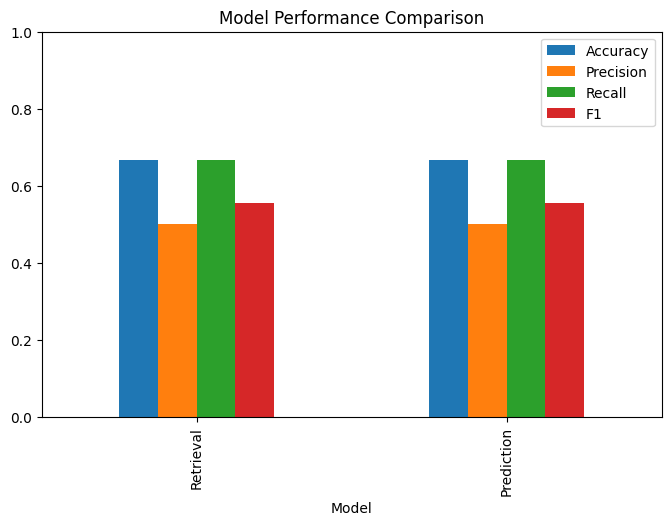

In [78]:
# VISUALISASI EVALUASI
import matplotlib.pyplot as plt
import pandas as pd

visual_df = pd.DataFrame({

"Model":[
"Retrieval",
"Prediction"
],

"Accuracy":[acc,acc2],
"Precision":[prec,prec2],
"Recall":[rec,rec2],
"F1":[f1,f12]

})

print(visual_df)

visual_df.plot(
x="Model",
kind="bar",
figsize=(8,5)
)

plt.title(
"Model Performance Comparison"
)

plt.ylim(0,1)

plt.show()

In [79]:
# SIMPAN DETAIL EVALUASI
retrieval_eval.to_csv(
"/content/data/eval/retrieval_detail.csv",
index=False,
encoding="utf-8-sig"
)

prediction_eval.to_csv(
"/content/data/eval/prediction_detail.csv",
index=False,
encoding="utf-8-sig"
)

print(
"DETAIL EVALUATION SAVED"
)

DETAIL EVALUATION SAVED
